In [1]:
!pip install numpy matplotlib
import numpy as np
import math 
import matplotlib.pyplot as plt 
%matplotlib inline


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [2]:
def f(x):
    return x**2 + 4*x + 3

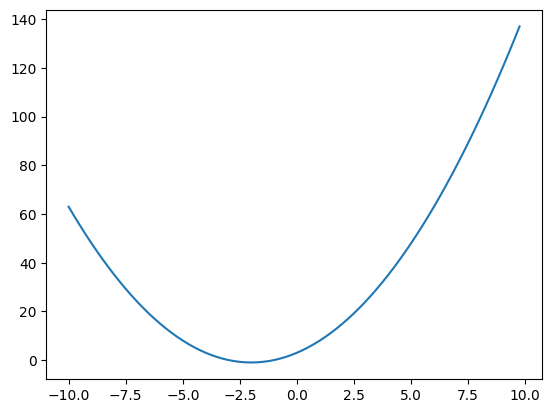

In [3]:
xs = np.arange(-10,10,0.25)
ys = f(xs)
plt.plot(xs,ys)

In [4]:
h = 0.000000001
x = 0
(f(x+h)-f(x))/h

3.9999998868722737

In [5]:
h = 0.0001
a = 1
b = 2
c = 3
d = a*b + c
b += h
d1 = a*b + c
print((d1-d)/h)

0.9999999999976694


In [19]:
class Value:
    def __init__ (self,data , _children=() , _op='' , label=''):
        self.data = data
        self._prev = set(_children)
        self._op = _op
        self.label = label
        self.grad = 0.0
    def __repr__(self):
        return f"Value(data={self.data} op={self._op})"
    def __add__(self,other):
        return Value(self.data + other.data , (self,other) , '+')
    def __mul__(self, other):
        return Value(self.data * other.data , (self,other) , '*')
a = Value(2.0 , label='a')
b = Value(3.0 , label='b')
c = Value(4.0 , label='c')
d = a * b ; d.label = 'd'
e = d + c ; e.label = 'e'
print(e)

Value(data=10.0 op=+)



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


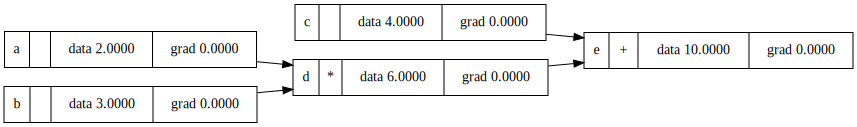

In [20]:
!pip install graphviz
from graphviz import Digraph
def trace(root):
    nodes , edges = set() , set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child,v))
                build(child)
    build(root)
    return nodes , edges
def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir':'LR'})
    nodes , edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        dot.node(name=uid , label="{ %s | %s | data %.4f | grad %.4f }" % (n.label , n._op , n.data , n.grad) , shape='record')
        if n._op:
            for child in n._prev:
                dot.edge(str(id(child)) , uid)
    return dot
draw_dot(e)